In [2]:
import requests
import pandas as pd
import joblib
import os
from datetime import datetime, timedelta

In [3]:
MODEL_DIR = "../models"

model_d1 = joblib.load(
    os.path.join(MODEL_DIR, "flood_model_d1.pkl")
)

model_d2 = joblib.load(
    os.path.join(MODEL_DIR, "flood_model_d2.pkl")
)

model_d3 = joblib.load(
    os.path.join(MODEL_DIR, "flood_model_d3.pkl")
)

model_features = joblib.load(
    os.path.join(MODEL_DIR, "model_features.pkl")
)

models = {
    "D+1": model_d1,
    "D+2": model_d2,
    "D+3": model_d3
}

print("Loaded models successfully")

for horizon, model in models.items():
    print(horizon, "->", type(model).__name__)

print("\nFeatures:")
print(model_features)

Loaded models successfully
D+1 -> XGBClassifier
D+2 -> XGBClassifier
D+3 -> XGBClassifier

Features:
['location_id', 'rainfall', 'temperature', 'humidity', 'pressure', 'wind_speed', 'river_discharge', 'month', 'rainfall_3d', 'rainfall_7d', 'discharge_change_1d']


In [4]:
LOCATION = "Hue"

# Nếu muốn Quảng Nam:
# LOCATION = "Quang Nam"

locations = {

    "Hue": {
        "latitude": 16.4637,
        "longitude": 107.5909
    },

    "Quang Nam": {
        "latitude": 15.5736,
        "longitude": 108.4740
    }
}

lat = locations[LOCATION]["latitude"]
lon = locations[LOCATION]["longitude"]

print("Location:", LOCATION)
print("Latitude:", lat)
print("Longitude:", lon)

Location: Hue
Latitude: 16.4637
Longitude: 107.5909


In [5]:
TRAIN_DATA_PATH = "../data/train/train_data.csv"

train_reference = pd.read_csv(
    TRAIN_DATA_PATH,
    usecols=[
        "location_id",
        "location"
    ]
).drop_duplicates()

location_mapping = dict(
    zip(
        train_reference["location"],
        train_reference["location_id"]
    )
)

LOCATION_ID = int(
    location_mapping[LOCATION]
)

print(location_mapping)

print(
    "Selected location_id:",
    LOCATION_ID
)

{'Hue': 1, 'Quang Nam': 2}
Selected location_id: 1


In [6]:
weather_url = (
    "https://api.open-meteo.com/v1/forecast"
)

weather_params = {

    "latitude": lat,

    "longitude": lon,

    "daily": [
        "temperature_2m_mean",
        "relative_humidity_2m_mean",
        "precipitation_sum",
        "pressure_msl_mean",
        "wind_speed_10m_max"
    ],

    "past_days": 7,

    "forecast_days": 1,

    "timezone": "Asia/Bangkok"
}

weather_response = requests.get(
    weather_url,
    params=weather_params,
    timeout=30
)

weather_response.raise_for_status()

weather_data = weather_response.json()

In [7]:
weather_df = pd.DataFrame({

    "date":
        weather_data["daily"]["time"],

    "rainfall":
        weather_data["daily"][
            "precipitation_sum"
        ],

    "temperature":
        weather_data["daily"][
            "temperature_2m_mean"
        ],

    "humidity":
        weather_data["daily"][
            "relative_humidity_2m_mean"
        ],

    "pressure":
        weather_data["daily"][
            "pressure_msl_mean"
        ],

    "wind_speed":
        weather_data["daily"][
            "wind_speed_10m_max"
        ]
})

weather_df["date"] = pd.to_datetime(
    weather_df["date"]
)

weather_df

,date,rainfall,temperature,humidity,pressure,wind_speed
0,2026-07-15,0.7,29.3,73,1005.5,15.7
1,2026-07-16,0.4,30.8,64,1006.0,11.9
2,2026-07-17,0.4,31.4,62,1005.5,14.3
3,2026-07-18,0.4,31.9,58,1004.8,11.2
4,2026-07-19,0.0,32.5,53,1005.2,12.6
5,2026-07-20,1.8,32.4,53,1005.6,16.9
6,2026-07-21,0.0,32.8,50,1006.3,17.3
7,2026-07-22,4.6,31.7,59,1006.7,13.9


In [8]:
flood_url = (
    "https://flood-api.open-meteo.com/v1/flood"
)

flood_params = {

    "latitude": lat,

    "longitude": lon,

    "daily": [
        "river_discharge"
    ],

    "past_days": 7,

    "forecast_days": 1,

    "timezone": "Asia/Bangkok"
}

flood_response = requests.get(
    flood_url,
    params=flood_params,
    timeout=30
)

flood_response.raise_for_status()

flood_data = flood_response.json()

In [7]:
river_df = pd.DataFrame({
    "date": flood_data["daily"]["time"],
    "river_discharge": flood_data["daily"]["river_discharge"],
    "river_discharge_mean": flood_data["daily"]["river_discharge_mean"],
    "river_discharge_max": flood_data["daily"]["river_discharge_max"],
    "river_discharge_min": flood_data["daily"]["river_discharge_min"]
})

river_df["date"] = pd.to_datetime(river_df["date"])

river_df

,date,river_discharge,river_discharge_mean,river_discharge_max,river_discharge_min
0,2026-07-04,1.19,1.29,2.18,1.19
1,2026-07-05,1.50,2.18,9.57,0.87
2,2026-07-06,1.74,2.69,10.94,0.64
3,2026-07-07,1.11,1.75,5.25,0.53
4,2026-07-08,0.69,1.17,4.97,0.44
5,2026-07-09,0.53,0.96,2.75,0.39
6,2026-07-10,0.44,0.93,4.22,0.34


In [8]:
forecast = weather_df.merge(
    river_df,
    on="date",
    how="inner"
)

forecast

,date,rainfall,temperature,humidity,pressure,wind_speed,location,river_discharge,river_discharge_mean,river_discharge_max,river_discharge_min
0,2026-07-04,14.0,26.9,94,1004.8,12.7,Hue,1.19,1.29,2.18,1.19
1,2026-07-05,0.1,28.6,79,1006.2,8.7,Hue,1.50,2.18,9.57,0.87
2,2026-07-06,1.1,29.0,75,1005.8,11.4,Hue,1.74,2.69,10.94,0.64
3,2026-07-07,0.1,29.3,73,1004.6,9.4,Hue,1.11,1.75,5.25,0.53
4,2026-07-08,0.4,29.8,69,1003.5,9.7,Hue,0.69,1.17,4.97,0.44
5,2026-07-09,4.2,29.7,73,1003.1,9.4,Hue,0.53,0.96,2.75,0.39
6,2026-07-10,0.6,30.0,72,1001.8,18.3,Hue,0.44,0.93,4.22,0.34


In [9]:
forecast = forecast.sort_values("date").reset_index(drop=True)

forecast["rainfall_3days"] = (
    forecast["rainfall"]
    .rolling(window=3, min_periods=1)
    .sum()
)

forecast["rainfall_7days"] = (
    forecast["rainfall"]
    .rolling(window=7, min_periods=1)
    .sum()
)

forecast["river_discharge_change"] = (
    forecast["river_discharge"]
    .diff()
    .fillna(0)
)

forecast["month"] = forecast["date"].dt.month

def get_season(month):
    if month in [9, 10, 11, 12]:
        return "Rainy"
    else:
        return "Dry"

forecast["season"] = forecast["month"].apply(get_season)

forecast

,date,rainfall,temperature,humidity,pressure,wind_speed,location,river_discharge,river_discharge_mean,river_discharge_max,river_discharge_min,rainfall_3days,rainfall_7days,river_discharge_change,month,season
0,2026-07-04,14.0,26.9,94,1004.8,12.7,Hue,1.19,1.29,2.18,1.19,14.0,14.0,0.00,7,Dry
1,2026-07-05,0.1,28.6,79,1006.2,8.7,Hue,1.50,2.18,9.57,0.87,14.1,14.1,0.31,7,Dry
2,2026-07-06,1.1,29.0,75,1005.8,11.4,Hue,1.74,2.69,10.94,0.64,15.2,15.2,0.24,7,Dry
3,2026-07-07,0.1,29.3,73,1004.6,9.4,Hue,1.11,1.75,5.25,0.53,1.3,15.3,-0.63,7,Dry
4,2026-07-08,0.4,29.8,69,1003.5,9.7,Hue,0.69,1.17,4.97,0.44,1.6,15.7,-0.42,7,Dry
5,2026-07-09,4.2,29.7,73,1003.1,9.4,Hue,0.53,0.96,2.75,0.39,4.7,19.9,-0.16,7,Dry
6,2026-07-10,0.6,30.0,72,1001.8,18.3,Hue,0.44,0.93,4.22,0.34,5.2,20.5,-0.09,7,Dry


In [10]:
#target_day = forecast.iloc[[1]].copy()
# target_day = forecast.iloc[[2]].copy()
# target_day = forecast.iloc[[3]].copy()
target_day = forecast.iloc[[0]].copy()

target_day

,date,rainfall,temperature,humidity,pressure,wind_speed,location,river_discharge,river_discharge_mean,river_discharge_max,river_discharge_min,rainfall_3days,rainfall_7days,river_discharge_change,month,season
0,2026-07-04,14.0,26.9,94,1004.8,12.7,Hue,1.19,1.29,2.18,1.19,14.0,14.0,0.0,7,Dry


In [11]:
input_features = [
    "rainfall",
    "temperature",
    "humidity",
    "pressure",
    "wind_speed",
    "river_discharge",
    "rainfall_3days",
    "rainfall_7days",
    "river_discharge_change",
    "month",
    "season",
    "location"
]

input_data = target_day[input_features].copy()

input_data = pd.get_dummies(input_data)

input_data = input_data.reindex(
    columns=model_features,
    fill_value=0
)

input_data

,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,rainfall_3days,rainfall_7days,river_discharge_change,month,season_Dry,season_Rainy,location_Hue,location_Quang Nam
0,14.0,26.9,94,1004.8,12.7,1.19,14.0,14.0,0.0,7,True,0,True,0


In [ ]:
predictions = {}

for day, model in rf_models.items():
    prob = model.predict_proba(input_data)[:, 1][0]
    risk_score = round(prob * 100, 2)
    
    predictions[day] = {
        "flood_probability": round(prob, 4),
        "flood_risk_score": risk_score
    }

predictions

{'D+1': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0)},
 'D+2': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0)},
 'D+3': {'flood_probability': np.float64(0.0033),
  'flood_risk_score': np.float64(0.33)}}

In [13]:
def get_alert_level(score):
    if score < 20:
        return "Green"
    elif score < 40:
        return "Yellow"
    elif score < 60:
        return "Orange"
    elif score < 80:
        return "Red"
    else:
        return "Severe Red"


for day in predictions:
    predictions[day]["alert_level"] = get_alert_level(
        predictions[day]["flood_risk_score"]
    )

predictions

{'D+1': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0),
  'alert_level': 'Green'},
 'D+2': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0),
  'alert_level': 'Green'},
 'D+3': {'flood_probability': np.float64(0.0033),
  'flood_risk_score': np.float64(0.33),
  'alert_level': 'Green'}}

In [14]:
def get_river_trend(change):
    if change > 10:
        return "Increasing"
    elif change < -10:
        return "Decreasing"
    else:
        return "Stable"


river_trend = get_river_trend(
    target_day["river_discharge_change"].iloc[0]
)

river_trend

'Stable'

In [15]:
def get_recommendation(score):
    if score < 20:
        return "Normal condition. Continue monitoring."
    elif score < 40:
        return "Low risk. Monitor weather updates."
    elif score < 60:
        return "Moderate risk. Prepare emergency supplies."
    elif score < 80:
        return "High risk. Avoid low-lying areas and riverside roads."
    else:
        return "Severe risk. Prepare evacuation and follow official warnings."


for day in predictions:
    score = predictions[day]["flood_risk_score"]
    predictions[day]["recommendation"] = get_recommendation(score)

predictions

{'D+1': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0),
  'alert_level': 'Green',
  'recommendation': 'Normal condition. Continue monitoring.'},
 'D+2': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0),
  'alert_level': 'Green',
  'recommendation': 'Normal condition. Continue monitoring.'},
 'D+3': {'flood_probability': np.float64(0.0033),
  'flood_risk_score': np.float64(0.33),
  'alert_level': 'Green',
  'recommendation': 'Normal condition. Continue monitoring.'}}

In [16]:
risk_factors = []

row = target_day.iloc[0]

if row["rainfall"] > 50:
    risk_factors.append("Heavy rainfall")

if row["rainfall_3days"] > 100:
    risk_factors.append("High accumulated rainfall in 3 days")

if row["rainfall_7days"] > 200:
    risk_factors.append("High accumulated rainfall in 7 days")

if row["river_discharge_change"] > 10:
    risk_factors.append("Increasing river discharge")

if row["season"] == "Rainy":
    risk_factors.append("Rainy season")

risk_factors

[]

In [17]:
from datetime import timedelta

results = []

base_date = pd.to_datetime(
    target_day["date"].iloc[0]
)

for day in predictions:

    horizon = int(day.replace("D+", ""))

    forecast_date = (
        base_date +
        timedelta(days=horizon)
    )

    confidence = max(
        predictions[day]["flood_probability"],
        1 - predictions[day]["flood_probability"]
    )

    result = {
        "location": LOCATION,
        "base_date": base_date,
        "forecast_date": forecast_date,
        "forecast_horizon": day,
        "flood_probability":
        predictions[day]["flood_probability"],
        "flood_risk_score": predictions[day]["flood_risk_score"],
        "confidence_score": round(confidence * 100,2),
        "alert_level": predictions[day]["alert_level"],
        "river_trend": river_trend,
        "main_risk_factors": ", ".join(risk_factors),
        "recommendation": predictions[day]["recommendation"]
    }

    results.append(result)

results_df = pd.DataFrame(results)

results_df

,location,base_date,forecast_date,forecast_horizon,flood_probability,flood_risk_score,confidence_score,alert_level,river_trend,main_risk_factors,recommendation
0,Hue,2026-07-04,2026-07-05,D+1,0.0000,0.00,100.00,Green,Stable,,Normal condition. Continue monitoring.
1,Hue,2026-07-04,2026-07-06,D+2,0.0000,0.00,100.00,Green,Stable,,Normal condition. Continue monitoring.
2,Hue,2026-07-04,2026-07-07,D+3,0.0033,0.33,99.67,Green,Stable,,Normal condition. Continue monitoring.


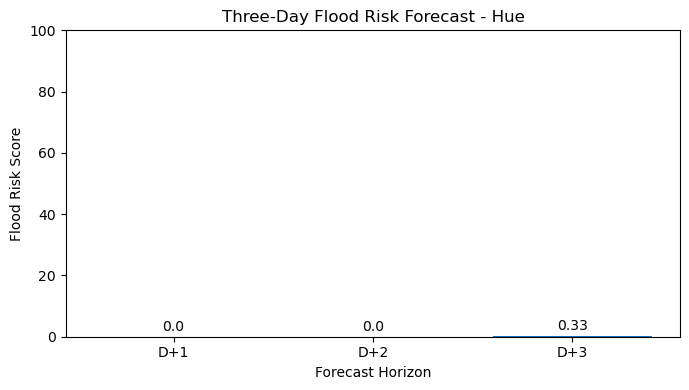

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(
    results_df["forecast_horizon"],
    results_df["flood_risk_score"]
)

plt.ylim(0, 100)
plt.xlabel("Forecast Horizon")
plt.ylabel("Flood Risk Score")
plt.title(f"Three-Day Flood Risk Forecast - {LOCATION}")

for i, score in enumerate(results_df["flood_risk_score"]):
    plt.text(
        i,
        score + 2,
        str(score),
        ha="center"
    )

plt.tight_layout()
plt.show()